# Etapa 2 — Segmentación de pasajeros con K-Medias

**TPI Ciencia de Datos — DS Airlines**

Este notebook aplica el algoritmo de agrupamiento **K-Medias** sobre el subconjunto de clientes que viajan en vuelos clasificados como demorados por el Árbol de Decisión (30.518 clientes únicos, salida del notebook anterior `04_Aplicacion_Arbol_CasosNuevos.ipynb`).

**Decisión metodológica:** el documento general del trabajo plantea ajustar el clustering sobre los 50.000 clientes del dataset completo. En este notebook se decide alternativamente ajustar el modelo **directamente sobre el subconjunto de clientes demorados**, ya que son los únicos pasajeros a los que el agente inteligente va a asignar un beneficio compensatorio. Esto concentra la segmentación sobre la población realmente objetivo del problema de negocio.

**Pipeline aplicado, conforme a la sección de Preparación de Datos del documento:**

- Se conservan únicamente las **6 variables numéricas** definidas como vista minable: `edad`, `cant_vuelos`, `cantidad_millas`, `ingreso_mensual`, `anticipacion_compra_promedio` y `gasto_acumulado`.
- Se excluyen del modelado: `id_cliente` (conservada aparte para trazabilidad), `sexo` (sin poder discriminante), `gasto_acumulado_extra` (r = 0,906 con `gasto_acumulado`) y `provincia` (alta cardinalidad sin patrón claro).
- Las cuatro variables categóricas restantes (`ocupacion`, `clase_preferida`, `programaMillas`, `canal_compra`) se conservan **fuera del modelado** y se utilizan posteriormente para caracterizar los clusters obtenidos mediante tablas cruzadas.
- Se aplica **estandarización z-score** sobre las seis numéricas (decisión fundamentada en la presencia de outliers válidos del dominio que harían inadecuado un min-max).

## 1. Importaciones y configuración

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

sns.set_style('whitegrid')
RANDOM_STATE = 42

# Si se ejecuta en Colab, subir manualmente el archivo resultados_etapa2_arbol.xlsx
# from google.colab import files
# files.upload()

## 2. Carga del dataset de clientes demorados

Se carga la hoja `clientes_a_analizar` del archivo `resultados_etapa2_arbol.xlsx` generado por el notebook anterior. Este dataset contiene los 30.518 clientes únicos que viajan en al menos un vuelo predicho como demorado, con todos sus atributos originales del dataset Clientes.

In [ ]:
clientes = pd.read_excel('resultados_etapa2_arbol.xlsx', sheet_name='clientes_a_analizar')
print(f'Clientes a segmentar: {clientes.shape}')
clientes.head(3)

Clientes a segmentar: (30518, 14)


,id_cliente,sexo,provincia,edad,ocupacion,cant_vuelos,clase_preferida,gasto_acumulado,gasto_acumulado_extra,programaMillas,cantidad_millas,ingreso_mensual,anticipacion_compra_promedio,canal_compra
0,1,M,Salta,24,Comerciante,21,Económica,5731.62,1222.62,Sí,19113,1367,3,Agencia
1,2,F,Córdoba,49,Médico,16,Económica,2593.40,510.70,No,0,6252,30,App
2,3,M,Buenos Aires,41,Docente,10,Económica,2850.62,627.01,No,0,1593,16,App


In [ ]:
# Verificación: no debe haber valores nulos
print('Valores nulos por columna:')
print(clientes.isnull().sum().to_string())

Valores nulos por columna:
id_cliente                      0
sexo                            0
provincia                       0
edad                            0
ocupacion                       0
cant_vuelos                     0
clase_preferida                 0
gasto_acumulado                 0
gasto_acumulado_extra           0
programaMillas                  0
cantidad_millas                 0
ingreso_mensual                 0
anticipacion_compra_promedio    0
canal_compra                    0


## 3. Preparación de los datos

Se separan tres bloques conforme a las decisiones del documento:

- **id_cliente**: identificador, fuera del modelado, conservado para trazabilidad.
- **Variables numéricas para el clustering**: las seis variables de la vista minable.
- **Variables categóricas para caracterización posterior**: `ocupacion`, `clase_preferida`, `programaMillas`, `canal_compra`.

Las variables `sexo`, `gasto_acumulado_extra` y `provincia` se descartan por las razones documentadas.

In [ ]:
# Variables numéricas para el clustering
cols_numericas = ['edad', 'cant_vuelos', 'cantidad_millas', 'ingreso_mensual',
                  'anticipacion_compra_promedio', 'gasto_acumulado']

# Variables categóricas para caracterización posterior
cols_categoricas = ['ocupacion', 'clase_preferida', 'programaMillas', 'canal_compra']

# Trazabilidad
id_cliente = clientes['id_cliente'].copy()

# Bloques
X_num = clientes[cols_numericas].copy()
X_cat = clientes[cols_categoricas].copy()

print(f'Bloque numérico para clustering:    {X_num.shape}')
print(f'Bloque categórico para caracterización: {X_cat.shape}')
X_num.describe().round(2)

Bloque numérico para clustering:    (30518, 6)
Bloque categórico para caracterización: (30518, 4)


,edad,cant_vuelos,cantidad_millas,ingreso_mensual,anticipacion_compra_promedio,gasto_acumulado
count,30518.00,30518.00,30518.00,30518.00,30518.00,30518.00
mean,37.83,17.04,6683.51,3088.51,20.06,6556.16
std,11.49,15.78,23156.77,4145.57,21.62,12353.49
min,18.00,1.00,0.00,300.00,0.00,73.19
25%,29.00,6.00,0.00,1248.00,5.00,1400.28
50%,38.00,14.00,0.00,2091.00,13.00,3109.86
75%,46.00,21.00,0.00,3818.00,27.00,6311.94
max,80.00,99.00,541589.00,350075.00,180.00,253140.32


## 4. Estandarización z-score

Se aplica `StandardScaler` sobre las seis variables numéricas. Tras la transformación, cada variable tiene media 0 y desvío estándar 1, eliminando la dominancia de las variables de mayor magnitud (ingreso mensual, cantidad de millas y gasto acumulado) sobre las de menor escala (edad, anticipación de compra).

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num)
X_scaled = pd.DataFrame(X_scaled, columns=cols_numericas, index=X_num.index)

print('Estadísticos tras la estandarización:')
X_scaled.describe().round(4)

Estadísticos tras la estandarización:


,edad,cant_vuelos,cantidad_millas,ingreso_mensual,anticipacion_compra_promedio,gasto_acumulado
count,30518.0000,30518.0000,30518.0000,30518.0000,30518.0000,30518.0000
mean,0.0000,0.0000,-0.0000,-0.0000,-0.0000,-0.0000
std,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
min,-1.7255,-1.0170,-0.2886,-0.6727,-0.9279,-0.5248
25%,-0.7683,-0.7000,-0.2886,-0.4440,-0.6966,-0.4174
50%,0.0148,-0.1929,-0.2886,-0.2406,-0.3266,-0.2790
75%,0.7110,0.2508,-0.2886,0.1760,0.3210,-0.0198
max,3.6696,5.1952,23.0997,83.7019,7.3984,19.9610


## 5. Análisis cuantitativo del número de clusters

Se evalúan dos criterios complementarios sobre el rango k ∈ [2, 10]:

- **Inercia (método del codo)**: suma de las distancias cuadradas de cada observación a su centroide. Se busca el cambio de pendiente.
- **Coeficiente de silhouette promedio**: mide qué tan bien separados están los clusters. Cuanto más cercano a 1, mejor.

Dado el tamaño del dataset (~30.500 observaciones), el cálculo del silhouette se realiza sobre una muestra aleatoria de 5.000 puntos para mantener tiempos de cómputo razonables. El método del codo se calcula sobre todo el dataset.

In [ ]:
ks = list(range(2, 11))
inercias = []
silhouettes = []

for k in ks:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10,
                max_iter=300, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_scaled)
    inercias.append(km.inertia_)
    sil = silhouette_score(X_scaled, labels, sample_size=5000, random_state=RANDOM_STATE)
    silhouettes.append(sil)
    print(f'k = {k:2d}  |  Inercia = {km.inertia_:10.2f}  |  Silhouette = {sil:.4f}')

k =  2  |  Inercia =  137525.15  |  Silhouette = 0.5672
k =  3  |  Inercia =  117829.35  |  Silhouette = 0.2192
k =  4  |  Inercia =  102624.37  |  Silhouette = 0.2416
k =  5  |  Inercia =   88518.21  |  Silhouette = 0.2537
k =  6  |  Inercia =   79401.26  |  Silhouette = 0.2532
k =  7  |  Inercia =   73964.10  |  Silhouette = 0.2564
k =  8  |  Inercia =   68187.80  |  Silhouette = 0.2617
k =  9  |  Inercia =   63618.38  |  Silhouette = 0.2034
k = 10  |  Inercia =   59431.00  |  Silhouette = 0.2080


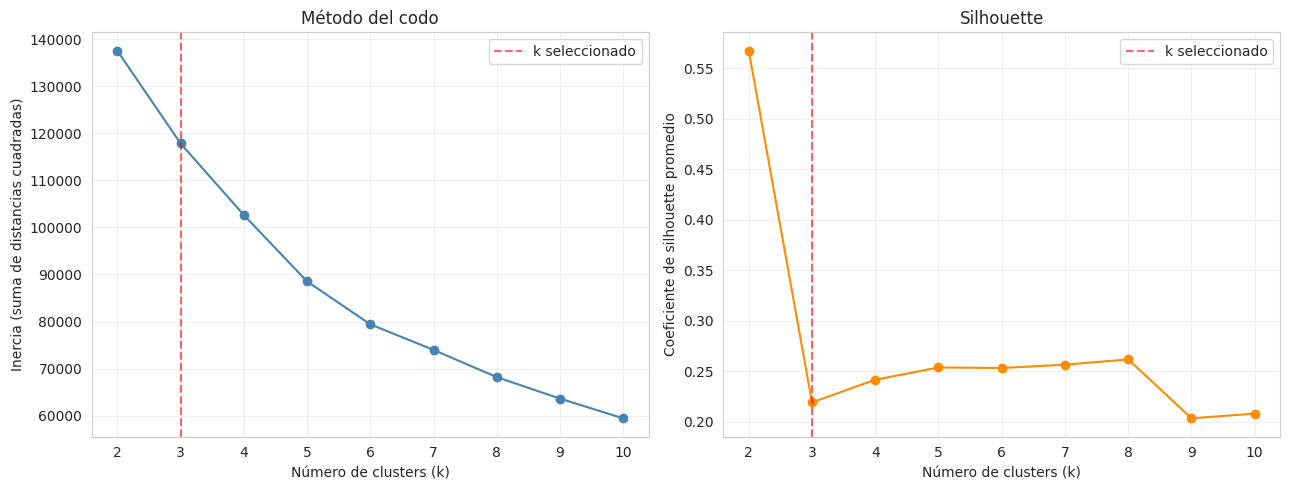

In [ ]:
# Gráfico combinado: codo + silhouette
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(ks, inercias, 'o-', color='steelblue')
axes[0].axvline(x=3, color='red', linestyle='--', alpha=0.6, label='k seleccionado')
axes[0].set_xlabel('Número de clusters (k)')
axes[0].set_ylabel('Inercia (suma de distancias cuadradas)')
axes[0].set_title('Método del codo')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(ks, silhouettes, 'o-', color='darkorange')
axes[1].axvline(x=3, color='red', linestyle='--', alpha=0.6, label='k seleccionado')
axes[1].set_xlabel('Número de clusters (k)')
axes[1].set_ylabel('Coeficiente de silhouette promedio')
axes[1].set_title('Silhouette')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Tabla resumen
df_k = pd.DataFrame({'k': ks, 'inercia': inercias, 'silhouette': silhouettes})
df_k['delta_inercia'] = df_k['inercia'].diff()
df_k['delta_inercia_%'] = (df_k['delta_inercia'] / df_k['inercia'].shift(1) * 100).round(2)
df_k.round(4)

,k,inercia,silhouette,delta_inercia,delta_inercia_%
0,2,137525.1457,0.5672,NaN,NaN
1,3,117829.3473,0.2192,-19695.7985,-14.32
2,4,102624.3743,0.2416,-15204.9729,-12.90
3,5,88518.2121,0.2537,-14106.1622,-13.75
4,6,79401.2615,0.2532,-9116.9507,-10.30
5,7,73964.0974,0.2564,-5437.1640,-6.85
6,8,68187.7968,0.2617,-5776.3007,-7.81
7,9,63618.3794,0.2034,-4569.4174,-6.70
8,10,59430.9996,0.2080,-4187.3798,-6.58


## 6. Selección del número de clusters

Los criterios estadísticos por sí solos no determinan unívocamente un valor de k:

- El **silhouette** alcanza un máximo en k = 2 (~0,57), pero ese valor refleja principalmente la separación del segmento premium del resto, no una segmentación accionable.
- El **método del codo** muestra una pendiente que se va aplanando progresivamente sin un punto de quiebre tajante.

A este análisis estadístico se suma una **restricción operativa del problema de negocio**, que es la que termina determinando el valor de k. El agente inteligente debe asignar a cada pasajero demorado uno de los beneficios compensatorios definidos por DS Airlines (voucher de comida o acceso a sala VIP). Esto impone dos límites prácticos sobre el número de segmentos:

- **k = 2 resulta insuficiente**: la brecha entre dos únicos grupos sería demasiado amplia y forzaría a tratar a perfiles muy distintos (por ejemplo, un estudiante ocasional y un adulto profesional) de manera idéntica.
- **k ≥ 4 resulta excesivo**: la aerolínea no dispone de tantos beneficios diferenciados como para justificar más de tres segmentos accionables, y los grupos adicionales generarían microsegmentaciones sin correlato en una decisión operativa.

Se selecciona **k = 3** como el valor que mejor compatibiliza los criterios estadísticos con la operativa del negocio, permitiendo definir tres perfiles claramente diferenciables y mapeables a las opciones de beneficio disponibles.

## 7. Entrenamiento del modelo final

In [ ]:
k_optimo = 3

kmeans_final = KMeans(
    n_clusters=k_optimo,
    init='k-means++',
    n_init=10,
    max_iter=300,
    random_state=RANDOM_STATE
)
clusters = kmeans_final.fit_predict(X_scaled)

print(f'Modelo K-Medias final entrenado con k = {k_optimo}')
print(f'  Inercia final:        {kmeans_final.inertia_:.2f}')
print(f'  Iteraciones:          {kmeans_final.n_iter_}')
print(f'\nDistribución de clientes por cluster (numerado):')
print(pd.Series(clusters).value_counts().sort_index().to_string())

Modelo K-Medias final entrenado con k = 3
  Inercia final:        117829.35
  Iteraciones:          9

Distribución de clientes por cluster (numerado):
0    13648
1     2654
2    14216


## 8. Asignación de nombres descriptivos a los clusters

Los identificadores numéricos asignados por K-Medias (0, 1, 2) no son interpretables por sí mismos y, además, pueden variar entre corridas o versiones de la librería. Para que la segmentación resulte directamente utilizable por el negocio, se asignan nombres descriptivos a cada cluster en función de sus características observadas.

La lógica de asignación se construye sobre los centroides en escala original:

- El cluster con **mayor gasto acumulado promedio** corresponde al perfil de mayor valor económico → **Cliente Premium**.
- De los dos clusters restantes, el de **menor edad promedio** corresponde al perfil joven → **Cliente Joven Ocasional**.
- El cluster de **mayor edad promedio** corresponde al perfil adulto estándar → **Cliente Adulto Frecuente**.

Esta asignación es robusta: si por algún motivo el orden numérico de los clusters cambia (otra semilla, otra versión de scikit-learn), los nombres seguirán correspondiendo al perfil correcto.

In [ ]:
# Centroides en escala original (para asignar nombres y para interpretación)
centroides_orig = pd.DataFrame(
    scaler.inverse_transform(kmeans_final.cluster_centers_),
    columns=cols_numericas
)
centroides_orig.index.name = 'cluster'

def asignar_nombres(centroides):
    """
    Asigna nombres descriptivos a cada cluster en base a sus características.
    Devuelve un diccionario {numero_cluster: nombre}.
    """
    nombres = {}
    # Premium: el de mayor gasto acumulado
    cluster_premium = int(centroides['gasto_acumulado'].idxmax())
    nombres[cluster_premium] = 'Cliente Premium'

    # De los otros dos, el más joven y el más adulto
    otros = [c for c in centroides.index if c != cluster_premium]
    edades = centroides.loc[otros, 'edad']
    nombres[int(edades.idxmin())] = 'Cliente Joven Ocasional'
    nombres[int(edades.idxmax())] = 'Cliente Adulto Frecuente'

    return nombres

nombres_clusters = asignar_nombres(centroides_orig)
print('Asignación de nombres:')
for k, v in sorted(nombres_clusters.items()):
    print(f'  Cluster {k} → {v}')

Asignación de nombres:
  Cluster 0 → Cliente Joven Ocasional
  Cluster 1 → Cliente Premium
  Cluster 2 → Cliente Adulto Frecuente


In [ ]:
# Aplicar los nombres al vector de etiquetas
clientes_clusterizado = clientes.copy()
clientes_clusterizado['cluster'] = clusters
clientes_clusterizado['segmento'] = clientes_clusterizado['cluster'].map(nombres_clusters)

print('Distribución de clientes por segmento:')
distrib = clientes_clusterizado['segmento'].value_counts()
distrib_pct = (distrib / distrib.sum() * 100).round(2)
resumen_distrib = pd.DataFrame({'n_clientes': distrib, 'porcentaje': distrib_pct})
resumen_distrib

Distribución de clientes por segmento:


,n_clientes,porcentaje
segmento,,
Cliente Adulto Frecuente,14216,46.58
Cliente Joven Ocasional,13648,44.72
Cliente Premium,2654,8.70


## 9. Centroides en escala original e interpretación

Los centroides traducidos a las unidades originales permiten leer cada segmento como un perfil de cliente directamente expresable en términos del negocio.

In [ ]:
# Reindexar centroides con los nombres descriptivos
centroides_orig_named = centroides_orig.copy()
centroides_orig_named.index = [nombres_clusters[c] for c in centroides_orig_named.index]
centroides_orig_named.index.name = 'segmento'

print('Centroides en escala original:')
centroides_orig_named.round(2)

Centroides en escala original:


,edad,cant_vuelos,cantidad_millas,ingreso_mensual,anticipacion_compra_promedio,gasto_acumulado
segmento,,,,,,
Cliente Joven Ocasional,28.33,11.73,2168.48,2250.31,25.83,3394.49
Cliente Premium,39.50,55.52,49878.56,8146.15,14.04,33186.95
Cliente Adulto Frecuente,46.65,14.97,2967.61,2950.81,15.64,4628.41


In [ ]:
# Centroides en espacio estandarizado (qué variables definen a cada segmento)
centroides_std_named = pd.DataFrame(kmeans_final.cluster_centers_, columns=cols_numericas)
centroides_std_named.index = [nombres_clusters[c] for c in centroides_std_named.index]
centroides_std_named.index.name = 'segmento'

print('Centroides en espacio z-score (lectura: cuán alejado del promedio general está cada segmento en cada variable):')
centroides_std_named.round(3)

Centroides en espacio z-score (lectura: cuán alejado del promedio general está cada segmento en cada variable):


,edad,cant_vuelos,cantidad_millas,ingreso_mensual,anticipacion_compra_promedio,gasto_acumulado
segmento,,,,,,
Cliente Joven Ocasional,-0.827,-0.337,-0.195,-0.202,0.267,-0.256
Cliente Premium,0.145,2.439,1.865,1.220,-0.278,2.156
Cliente Adulto Frecuente,0.768,-0.131,-0.160,-0.033,-0.204,-0.156


## 10. Visualización mediante PCA

El espacio de seis dimensiones sobre el que opera K-Medias no es directamente representable. Se aplica PCA sobre las **mismas variables estandarizadas** y se proyectan los clientes sobre los tres primeros componentes principales (la misma solución adoptada en el Modelado de ACP), coloreando por segmento asignado.

Esta visualización no constituye una validación cuantitativa del modelo, pero permite inspeccionar visualmente la separación de los grupos en las direcciones de mayor variabilidad del dataset. Se muestra primero la proyección sobre el plano (PC1, PC2), que recoge el 56,87% de la varianza y permite leer simultáneamente la separación por valor económico y por perfil generacional, y luego una proyección tridimensional que incorpora PC3 y acumula el 72,25% de la varianza total.

In [ ]:
pca = PCA(n_components=3, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print(f'Varianza explicada por PC1: {pca.explained_variance_ratio_[0]*100:.2f}%')
print(f'Varianza explicada por PC2: {pca.explained_variance_ratio_[1]*100:.2f}%')
print(f'Varianza explicada por PC3: {pca.explained_variance_ratio_[2]*100:.2f}%')
print(f'Varianza explicada acumulada (PC1 + PC2): {pca.explained_variance_ratio_[:2].sum()*100:.2f}%')
print(f'Varianza explicada acumulada (PC1 + PC2 + PC3): {pca.explained_variance_ratio_.sum()*100:.2f}%')

Varianza explicada por PC1: 39.31%
Varianza explicada por PC2: 17.56%
Varianza explicada por PC3: 15.38%
Varianza explicada acumulada (PC1 + PC2): 56.87%
Varianza explicada acumulada (PC1 + PC2 + PC3): 72.25%


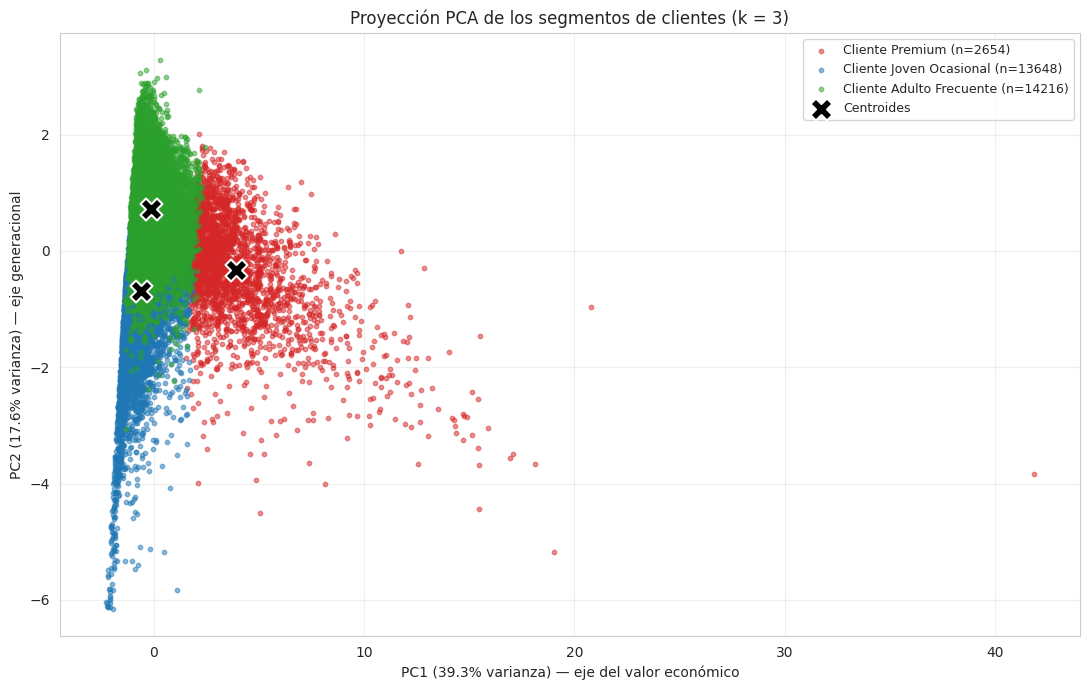

In [ ]:
# Scatter plot coloreado por segmento
plt.figure(figsize=(11, 7))

# Paleta con colores fijos por nombre de segmento (no depende del número de cluster)
colores_segmento = {
    'Cliente Premium': '#d62728',          # rojo
    'Cliente Adulto Frecuente': '#2ca02c', # verde
    'Cliente Joven Ocasional': '#1f77b4',  # azul
}

for nombre in nombres_clusters.values():
    mask = clientes_clusterizado['segmento'] == nombre
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], s=10, alpha=0.5,
                color=colores_segmento[nombre],
                label=f'{nombre} (n={mask.sum()})')

# Proyección de los centroides sobre el plano PCA
centroides_pca = pca.transform(pd.DataFrame(kmeans_final.cluster_centers_, columns=cols_numericas))
plt.scatter(centroides_pca[:, 0], centroides_pca[:, 1],
            s=250, c='black', marker='X', edgecolors='white',
            linewidths=1.5, label='Centroides', zorder=5)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza) — eje del valor económico')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza) — eje generacional')
plt.title(f'Proyección PCA de los segmentos de clientes (k = {k_optimo})')
plt.legend(loc='best', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

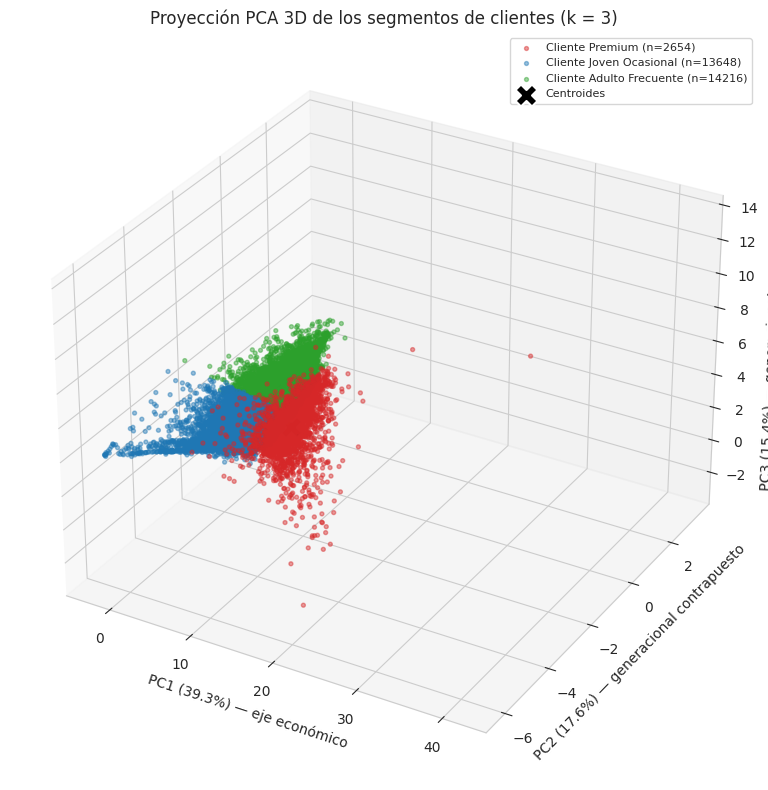

In [ ]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Definiciones locales (no dependen de la celda 25)
colores_segmento = {
    'Cliente Premium': '#d62728',          # rojo
    'Cliente Adulto Frecuente': '#2ca02c', # verde
    'Cliente Joven Ocasional': '#1f77b4',  # azul
}
centroides_pca = pca.transform(pd.DataFrame(kmeans_final.cluster_centers_, columns=cols_numericas))

fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection='3d')

for nombre in nombres_clusters.values():
    mask = clientes_clusterizado['segmento'] == nombre
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], X_pca[mask, 2],
               s=8, alpha=0.45,
               color=colores_segmento[nombre],
               label=f'{nombre} (n={mask.sum()})')

# Centroides en 3D
ax.scatter(centroides_pca[:, 0], centroides_pca[:, 1], centroides_pca[:, 2],
           s=250, c='black', marker='X', edgecolors='white',
           linewidths=1.5, label='Centroides')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%) — eje económico')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%) — generacional contrapuesto')
ax.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%) — generacional concordante')
ax.set_title(f'Proyección PCA 3D de los segmentos de clientes (k = {k_optimo})')
ax.legend(loc='best', fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
# Cargas (loadings) de las variables sobre cada componente
loadings = pd.DataFrame(pca.components_.T,
                        columns=['PC1', 'PC2', 'PC3'], index=cols_numericas)
print('Cargas de cada variable sobre los componentes principales:')
loadings.round(3)

Cargas de cada variable sobre los componentes principales:


,PC1,PC2,PC3
edad,0.114,0.706,0.674
cant_vuelos,0.535,-0.023,-0.026
cantidad_millas,0.491,-0.165,-0.062
ingreso_mensual,0.375,-0.007,0.160
anticipacion_compra_promedio,-0.116,-0.679,0.718
gasto_acumulado,0.553,-0.114,-0.017


## 11. Caracterización con variables categóricas

Aunque las categóricas no participaron del cómputo del modelo, su distribución dentro de cada segmento es central para la interpretación. Para cada categórica se construye una tabla cruzada con la etiqueta de segmento, expresada en porcentajes por fila (cada fila suma 100%).

In [ ]:
def tabla_cruzada_pct(df, col_cat, col_segmento='segmento'):
    tabla = pd.crosstab(df[col_segmento], df[col_cat], normalize='index') * 100
    return tabla.round(2)

In [ ]:
print('Distribución de ocupacion por segmento (%):')
tabla_cruzada_pct(clientes_clusterizado, 'ocupacion')

Distribución de ocupacion por segmento (%):


ocupacion,Abogado,Arquitecto,Comerciante,Contador,Deportista,Docente,Ejecutivo,Empleado,Empresario,Estudiante,Ingeniero,Jubilado,Médico,Otro,Profesional independiente
segmento,,,,,,,,,,,,,,,
Cliente Adulto Frecuente,5.32,4.12,8.29,4.97,1.16,10.25,4.42,23.19,5.23,0.00,7.57,2.24,6.62,6.04,10.57
Cliente Joven Ocasional,3.85,2.98,6.86,3.89,0.56,8.59,1.71,27.23,2.70,16.25,5.50,0.00,4.07,7.05,8.78
Cliente Premium,0.72,0.19,0.00,0.19,20.50,0.00,46.04,0.04,28.11,0.00,0.45,0.00,3.05,0.00,0.72


In [ ]:
print('Distribución de clase_preferida por segmento (%):')
tabla_cruzada_pct(clientes_clusterizado, 'clase_preferida')

Distribución de clase_preferida por segmento (%):


clase_preferida,Económica,Ejecutiva,Primera clase
segmento,,,
Cliente Adulto Frecuente,75.81,21.55,2.64
Cliente Joven Ocasional,80.43,18.06,1.51
Cliente Premium,32.40,44.91,22.68


In [ ]:
print('Distribución de programaMillas por segmento (%):')
tabla_cruzada_pct(clientes_clusterizado, 'programaMillas')

Distribución de programaMillas por segmento (%):


programaMillas,No,Sí
segmento,,
Cliente Adulto Frecuente,79.02,20.98
Cliente Joven Ocasional,80.17,19.83
Cliente Premium,39.22,60.78


In [ ]:
print('Distribución de canal_compra por segmento (%):')
tabla_cruzada_pct(clientes_clusterizado, 'canal_compra')

Distribución de canal_compra por segmento (%):


canal_compra,Aeropuerto,Agencia,App,Web
segmento,,,,
Cliente Adulto Frecuente,10.35,17.94,32.58,39.12
Cliente Joven Ocasional,7.45,11.02,42.36,39.17
Cliente Premium,9.01,14.66,35.04,41.30


## 12. Perfil resumen de cada segmento

Tabla integral que combina las medias de las variables numéricas (en escala original) con la categoría modal de cada variable categórica para cada segmento, junto con el tamaño en cantidad de clientes.

In [ ]:
# Medias numéricas por segmento
perfil_num = clientes_clusterizado.groupby('segmento')[cols_numericas].mean().round(2)

# Moda de cada categórica por segmento
perfil_cat = clientes_clusterizado.groupby('segmento')[cols_categoricas].agg(
    lambda x: x.mode().iloc[0] if not x.mode().empty else 'N/A'
)

# Tamaño del segmento
tamanio = clientes_clusterizado['segmento'].value_counts()
tamanio.name = 'n_clientes'

perfil = pd.concat([tamanio, perfil_num, perfil_cat], axis=1)

# Ordenar siguiendo una lógica de jerarquía de valor
orden_segmentos = ['Cliente Premium', 'Cliente Adulto Frecuente', 'Cliente Joven Ocasional']
perfil = perfil.reindex(orden_segmentos)

print('Perfil resumen de cada segmento:')
perfil

Perfil resumen de cada segmento:


,n_clientes,edad,cant_vuelos,cantidad_millas,ingreso_mensual,anticipacion_compra_promedio,gasto_acumulado,ocupacion,clase_preferida,programaMillas,canal_compra
segmento,,,,,,,,,,,
Cliente Premium,2654,39.50,55.51,49803.39,8140.63,14.03,33170.04,Ejecutivo,Ejecutiva,Sí,Web
Cliente Adulto Frecuente,14216,46.65,14.96,2968.85,2950.27,15.66,4620.83,Empleado,Económica,No,Web
Cliente Joven Ocasional,13648,28.32,11.73,2167.65,2250.05,25.82,3396.68,Empleado,Económica,No,App


## 13. Exportación de resultados

Se guarda un archivo Excel con:

- **`clientes_con_segmento`**: dataset completo de clientes demorados con el número de cluster y el nombre del segmento asignados.
- **`centroides_originales`**: centroides expresados en las unidades originales de cada variable.
- **`perfil_segmentos`**: tabla resumen con medias numéricas, moda de cada categórica y tamaño del segmento.

In [ ]:
archivo_salida = 'resultados_kmedias.xlsx'

with pd.ExcelWriter(archivo_salida, engine='openpyxl') as writer:
    clientes_clusterizado.to_excel(writer, sheet_name='clientes_con_segmento', index=False)
    centroides_orig_named.to_excel(writer, sheet_name='centroides_originales')
    perfil.to_excel(writer, sheet_name='perfil_segmentos')

print(f'Archivo generado: {archivo_salida}')
print(f'  - clientes_con_segmento: {len(clientes_clusterizado)} filas')
print(f'  - centroides_originales: {len(centroides_orig_named)} filas (1 por segmento)')
print(f'  - perfil_segmentos:      {len(perfil)} filas')

Archivo generado: resultados_kmedias.xlsx
  - clientes_con_segmento: 30518 filas
  - centroides_originales: 3 filas (1 por segmento)
  - perfil_segmentos:      3 filas


## 14. Cierre

Este notebook entrega:

1. Un análisis cuantitativo del número de clusters (codo + silhouette para k ∈ [2, 10]).
2. La selección de **k = 3** justificada por la combinación de criterios estadísticos y restricciones del negocio (cantidad limitada de beneficios diferenciables).
3. Un modelo K-Medias entrenado sobre las seis variables numéricas estandarizadas del subconjunto de clientes demorados.
4. Tres segmentos descriptivamente nombrados (Cliente Premium, Cliente Adulto Frecuente, Cliente Joven Ocasional), asignados mediante una lógica robusta basada en las características de cada cluster.
5. Una visualización PCA de los segmentos sobre los tres ejes latentes del dataset (valor económico, generacional contrapuesto y generacional concordante), tanto en una proyección bidimensional sobre PC1 y PC2 (56,87% de la varianza) como en una proyección tridimensional que incorpora PC3 (72,25% acumulado).
6. La caracterización de los segmentos mediante tablas cruzadas con las cuatro variables categóricas conservadas.
7. Un dataset enriquecido con número de cluster y nombre del segmento por cliente, listo para alimentar las próximas etapas (comparación con Cluster Jerárquico y Bietápico, y asignación final de beneficio compensatorio).